# Machine Learning I (CC2008) — Trabalho Prático
## Fase 1: Random Forest com Class Imbalance

**Algoritmo escolhido:** Random Forest  
**Desafio escolhido:** Class Imbalance (Grupo 2)  

Neste notebook avaliamos como o Random Forest se comporta quando os dados têm muito mais exemplos de uma classe do que de outra. A ideia é perceber onde é que o algoritmo falha antes de propor melhorias na Fase 2.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from collections import Counter

from mla.ensemble.random_forest import RandomForestClassifier

np.random.seed(42)
print("Tudo importado!")

Tudo importado!


## 2. Como funciona o Random Forest?

O Random Forest é um algoritmo que treina várias árvores de decisão ao mesmo tempo e combina as suas respostas. A ideia é simples: em vez de confiar numa única árvore (que pode cometer erros), usamos muitas árvores e fazemos uma "votação" — a classe que a maioria das árvores escolher é a resposta final.

Para garantir que as árvores são diferentes entre si (e não estão todas a aprender a mesma coisa), o algoritmo usa dois truques:

- **Bootstrap sampling:** cada árvore é treinada numa amostra aleatória *com reposição* do dataset original — ou seja, alguns exemplos aparecem mais do que uma vez e outros não aparecem. Isto introduz diversidade entre as árvores.
- **Feature randomness:** em cada divisão da árvore, só se consideram algumas features escolhidas aleatoriamente (em vez de todas). Assim as árvores não ficam todas iguais.

No final, para classificação, a previsão de cada árvore é uma distribuição de probabilidades por classe, e a média dessas probabilidades de todas as árvores dá a previsão final.

### O que descobrimos no código base

Ao analisar o código disponibilizado, encontrámos uma limitação importante: **o bootstrap sampling não está implementado**. Todas as árvores são treinadas com o dataset completo, sem qualquer amostragem. Isto significa que não há diversidade real entre as árvores — estão todas a ver os mesmos dados.

Esta limitação agrava o problema do class imbalance, como veremos a seguir.

### Porquê o Class Imbalance é um problema para o Random Forest?

Imagina um dataset em que 95% dos exemplos são da classe 0 e só 5% são da classe 1. O que acontece ao Random Forest?

1. **O critério de entropia fica enviesado:** ao procurar o melhor split, o algoritmo tende a favorecer divisões que acertam na classe maioritária (porque são a grande maioria dos exemplos)
2. **As árvores aprendem a "jogar pelo seguro":** como a classe 0 domina, as árvores aprendem que dizer sempre "classe 0" minimiza o erro — mesmo que isso signifique nunca identificar a classe 1
3. **Sem bootstrap real, o problema é ainda pior:** como todas as árvores veem os mesmos dados desequilibrados, não há nenhuma árvore que por acaso veja mais exemplos da classe minoritária

**A nossa hipótese:** à medida que o desequilíbrio aumenta, o modelo vai ter uma accuracy artificialmente alta mas um desempenho muito fraco na classe minoritária — que é normalmente a mais importante (fraudes, doenças raras, etc.).


## 3. Datasets

Usamos os **datasets disponibilizados pelo professor** para o Grupo 2 (Class Imbalance). São carregados todos os ficheiros presentes na pasta `class_imbalance/`, cobrindo diferentes níveis de desequilíbrio medido pelo **Imbalance Ratio (IR)**:

> IR = nº de exemplos da classe maioritária / nº de exemplos da classe minoritária

**Nota de pré-processamento:** Os datasets que contêm valores em falta (NaN) são tratados com imputação pela mediana (colunas numéricas) e moda (colunas categóricas). As colunas categóricas são codificadas com `LabelEncoder`. O target é sempre binarizado como 0 (maioritária) / 1 (minoritária).


In [2]:
def calcular_ir(y):
    """Calcula o Imbalance Ratio do dataset."""
    counter = Counter(y)
    return max(counter.values()) / min(counter.values())


def resumo_dataset(nome, X, y):
    counter = Counter(y)
    ir = calcular_ir(y)
    print(f"Dataset: {nome}")
    print(f"  Amostras: {X.shape[0]}  |  Features: {X.shape[1]}")
    print(f"  Classe 0 (maioritária): {counter[0]}  |  Classe 1 (minoritária): {counter[1]}")
    print(f"  Imbalance Ratio: {ir:.1f}:1")
    print()


def carregar_dataset(filepath):
    """
    Carrega um dataset CSV do professor:
    - A última coluna é o target
    - Colunas categóricas são codificadas com LabelEncoder
    - NaNs são imputados (mediana para numéricos, moda para categóricos)
    - Retorna X (numpy array float64) e y (numpy array int 0/1)
      onde 1 é sempre a classe minoritária
    """
    df = pd.read_csv(filepath)
    target_col = df.columns[-1]

    X_df = df.drop(columns=[target_col]).copy()
    y_raw = df[target_col].copy()

    # Imputar NaNs
    for col in X_df.columns:
        if X_df[col].isnull().any():
            if pd.api.types.is_numeric_dtype(X_df[col]):
                X_df[col] = X_df[col].fillna(X_df[col].median())
            else:
                X_df[col] = X_df[col].fillna(X_df[col].mode()[0])

    # Codificar colunas categóricas
    for col in X_df.columns:
        if not pd.api.types.is_numeric_dtype(X_df[col]):
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

    X = X_df.values.astype(np.float64)

    # Codificar target como 0/1
    le = LabelEncoder()
    y = le.fit_transform(y_raw.astype(str))

    # Garantir que a classe minoritária é o label 1
    counts = Counter(y)
    if counts[0] < counts[1]:
        y = 1 - y

    return X, y


print("Funções definidas!")

Funções definidas!


### Seleção dos 5 datasets

Dos ~50 datasets disponíveis na pasta `class_imbalance/`, selecionámos um conjunto que cobre o espectro completo de desequilíbrio de classes medido pelo **Imbalance Ratio (IR)**. O objetivo é ter pontos de referência distribuídos ao longo do eixo de IR para que a análise mostre claramente a degradação do desempenho à medida que o desequilíbrio aumenta.

| Dataset | IR | Amostras | Features | Porquê interessante |
|---|---|---|---|---|
| `dataset_1000_hypothyroid` | ≈ 12.0 | 3 772 | 29 | Desequilíbrio moderado; dataset real de diagnóstico médico |
| `dataset_38_sick` | ≈ 15.3 | 3 772 | 29 | Mesmo domínio do hypothyroid mas IR mais alto — bom par de comparação |
| `dataset_311_oil_spill` | ≈ 21.9 | 937 | 49 | Desequilíbrio alto; domínio ambiental com classes claramente separadas |
| `dataset_316_yeast_ml8` | ≈ 70.1 | 2 417 | 116 | Desequilíbrio muito alto; mostra o colapso do F1 minoritário |
| `dataset_1056_mc1` | ≈ 138.2 | 9 466 | 38 | Desequilíbrio extremo; caso limite que ilustra o pior cenário |

A distribuição cobre uma gama ampla de IR (de ~12:1 a ~138:1), garantindo que a tendência de degradação é visível nos gráficos da secção 4 e 6.

In [3]:
DATA_PATH = "class_imbalance/"

# 5 datasets spanning the full IR range (low → extreme imbalance)
SELECTED = [
    "dataset_1000_hypothyroid.csv", # IR ≈ 12.0  — moderate imbalance
    "dataset_38_sick.csv",          # IR ≈ 15.3  — medium-high imbalance
    "dataset_311_oil_spill.csv",    # IR ≈ 21.9  — high imbalance
    "dataset_316_yeast_ml8.csv",    # IR ≈ 70.1  — very high imbalance
    "dataset_1056_mc1.csv",         # IR ≈ 138.2 — extreme imbalance
]

datasets = []  # lista de tuplos (X, y, nome)

for fname in SELECTED:
    fpath = os.path.join(DATA_PATH, fname)
    X, y = carregar_dataset(fpath)
    nome = fname.replace(".csv", "")
    datasets.append((X, y, nome))
    resumo_dataset(nome, X, y)

print(f"Total de datasets carregados: {len(datasets)}")

Dataset: dataset_1000_hypothyroid
  Amostras: 3772  |  Features: 29
  Classe 0 (maioritária): 3481  |  Classe 1 (minoritária): 291
  Imbalance Ratio: 12.0:1

Dataset: dataset_38_sick
  Amostras: 3772  |  Features: 29
  Classe 0 (maioritária): 3541  |  Classe 1 (minoritária): 231
  Imbalance Ratio: 15.3:1

Dataset: dataset_311_oil_spill
  Amostras: 937  |  Features: 49
  Classe 0 (maioritária): 896  |  Classe 1 (minoritária): 41
  Imbalance Ratio: 21.9:1

Dataset: dataset_316_yeast_ml8
  Amostras: 2417  |  Features: 116
  Classe 0 (maioritária): 2383  |  Classe 1 (minoritária): 34
  Imbalance Ratio: 70.1:1

Dataset: dataset_1056_mc1
  Amostras: 9466  |  Features: 38
  Classe 0 (maioritária): 9398  |  Classe 1 (minoritária): 68
  Imbalance Ratio: 138.2:1

Total de datasets carregados: 5


C:\Users\ruidi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ruidi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## 4. Visualização do Desequilíbrio

Antes de treinar qualquer modelo, é útil ver graficamente o quão desequilibrados estão os datasets, ordenados por IR crescente.


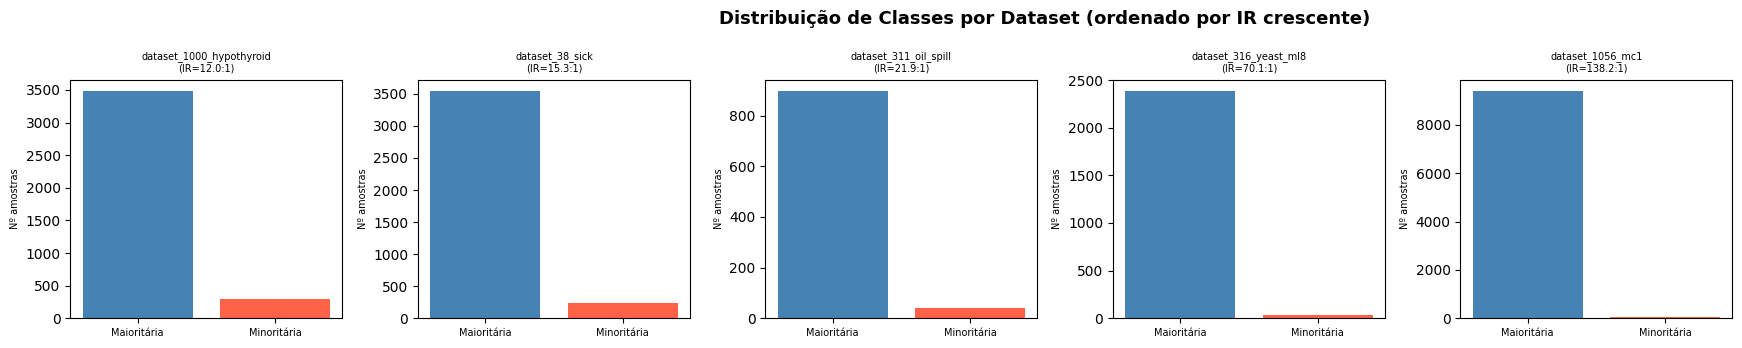

In [4]:
# Ordenar datasets por IR crescente
datasets_sorted = sorted(datasets, key=lambda t: calcular_ir(t[1]))

n = len(datasets_sorted)
cols = 6
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
axes = axes.flatten()

for i, (X, y, nome) in enumerate(datasets_sorted):
    counter = Counter(y)
    ir = calcular_ir(y)
    axes[i].bar([0, 1], [counter[0], counter[1]], color=["steelblue", "tomato"])
    axes[i].set_title(f"{nome}\n(IR={ir:.1f}:1)", fontsize=7)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Maioritária", "Minoritária"], fontsize=7)
    axes[i].set_ylabel("Nº amostras", fontsize=7)

# Esconder eixos vazios
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuição de Classes por Dataset (ordenado por IR crescente)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("distribuicao_classes.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Avaliação do Modelo

### Como avaliamos?

Usamos **Stratified K-Fold** com k=5 para acelerar a avaliação. A versão estratificada é importante aqui porque garante que cada fold tem a mesma proporção de classes que o dataset original — sem isso, podíamos ter folds onde a classe minoritária quase não aparece.

### Que métricas usamos?

Só usar a **accuracy** seria um erro grave com datasets desequilibrados. Por exemplo, num dataset com IR=70:1, um modelo que diga sempre "classe 0" tem ~99% de accuracy — mas não serve para nada!

Por isso usamos:
- **Accuracy** — incluímos só para mostrar que é enganosa
- **F1-score da classe minoritária** — a métrica mais importante: mede se o modelo consegue mesmo identificar a classe rara
- **F1 Macro** — média do F1 de ambas as classes, penaliza o modelo se ignorar alguma delas
- **AUC-ROC** — mede a capacidade do modelo de separar as classes, independentemente do threshold


In [19]:
def avaliar_rf(X, y, nome_dataset, n_estimators=10, max_depth=10, min_samples_split=5, n_splits=5):
    """Avalia o Random Forest com Stratified K-Fold e devolve as métricas médias."""

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accs, f1s_macro, f1s_min, aucs = [], [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split
        )
        rf.fit(X_train, y_train)

        probs = rf.predict(X_test)
        y_pred = np.argmax(probs, axis=1)

        accs.append(np.mean(y_pred == y_test))
        f1s_macro.append(f1_score(y_test, y_pred, average="macro", zero_division=0))
        f1s_min.append(f1_score(y_test, y_pred, pos_label=1, average="binary", zero_division=0))

        try:
            aucs.append(roc_auc_score(y_test, probs[:, 1]))
        except Exception:
            aucs.append(float("nan"))

    return {
        "Dataset": nome_dataset,
        "IR": calcular_ir(y),
        "Accuracy": np.mean(accs),
        "F1 Macro": np.mean(f1s_macro),
        "F1 Minoritária": np.mean(f1s_min),
        "AUC-ROC": np.nanmean(aucs),
    }


print("Função definida!")

Função definida!


In [20]:
resultados = []
for X, y, nome in datasets:
    print(f"A avaliar: {nome}...")
    res = avaliar_rf(X, y, nome)
    resultados.append(res)
    print(f"  IR: {res['IR']:.1f} | Accuracy: {res['Accuracy']:.3f} | F1 Macro: {res['F1 Macro']:.3f} | F1 Min: {res['F1 Minoritária']:.3f} | AUC: {res['AUC-ROC']:.3f}")

df_resultados = pd.DataFrame(resultados).sort_values("IR").reset_index(drop=True).round(3)
print("\nConcluído!")

A avaliar: dataset_1000_hypothyroid...
  IR: 12.0 | Accuracy: 0.937 | F1 Macro: 0.639 | F1 Min: 0.311 | AUC: 0.991
A avaliar: dataset_38_sick...
  IR: 15.3 | Accuracy: 0.942 | F1 Macro: 0.528 | F1 Min: 0.087 | AUC: 0.950
A avaliar: dataset_311_oil_spill...
  IR: 21.9 | Accuracy: 0.957 | F1 Macro: 0.548 | F1 Min: 0.117 | AUC: 0.799
A avaliar: dataset_316_yeast_ml8...
  IR: 70.1 | Accuracy: 0.986 | F1 Macro: 0.496 | F1 Min: 0.000 | AUC: 0.775
A avaliar: dataset_1056_mc1...
  IR: 138.2 | Accuracy: 0.993 | F1 Macro: 0.498 | F1 Min: 0.000 | AUC: 0.732

Concluído!


## 6. Resultados

In [7]:
print(df_resultados.to_string(index=False))

                 Dataset      IR  Accuracy  F1 Macro  F1 Minoritária  AUC-ROC
dataset_1000_hypothyroid  11.962     0.946     0.717           0.462    0.893
         dataset_38_sick  15.329     0.950     0.613           0.252    0.918
   dataset_311_oil_spill  21.854     0.964     0.661           0.340    0.768
   dataset_316_yeast_ml8  70.088     0.986     0.496           0.000    0.813
        dataset_1056_mc1 138.206     0.994     0.652           0.308    0.721


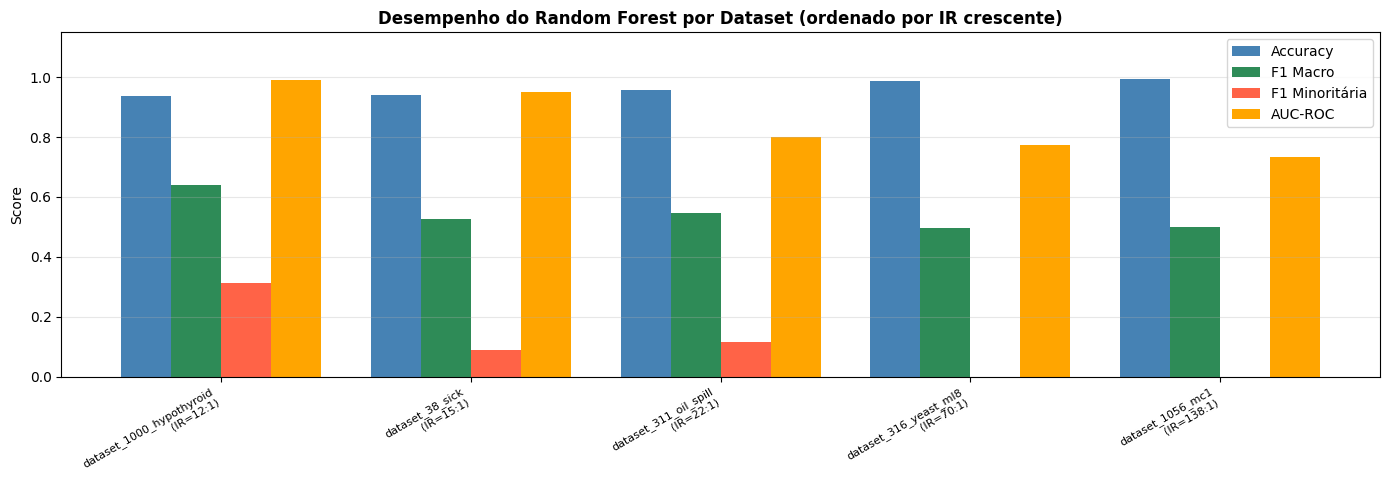

In [21]:
# Gráfico de barras: métricas por dataset, ordenado por IR crescente
fig, ax = plt.subplots(figsize=(max(14, len(df_resultados) * 0.8), 5))

x = np.arange(len(df_resultados))
width = 0.2

ax.bar(x - width*1.5, df_resultados["Accuracy"],       width, label="Accuracy",        color="steelblue")
ax.bar(x - width*0.5, df_resultados["F1 Macro"],       width, label="F1 Macro",        color="seagreen")
ax.bar(x + width*0.5, df_resultados["F1 Minoritária"], width, label="F1 Minoritária",  color="tomato")
ax.bar(x + width*1.5, df_resultados["AUC-ROC"],        width, label="AUC-ROC",         color="orange")

labels = [f"{row['Dataset']}\n(IR={row['IR']:.0f}:1)" for _, row in df_resultados.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Desempenho do Random Forest por Dataset (ordenado por IR crescente)", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("resultados_fase1.png", dpi=150, bbox_inches="tight")
plt.show()

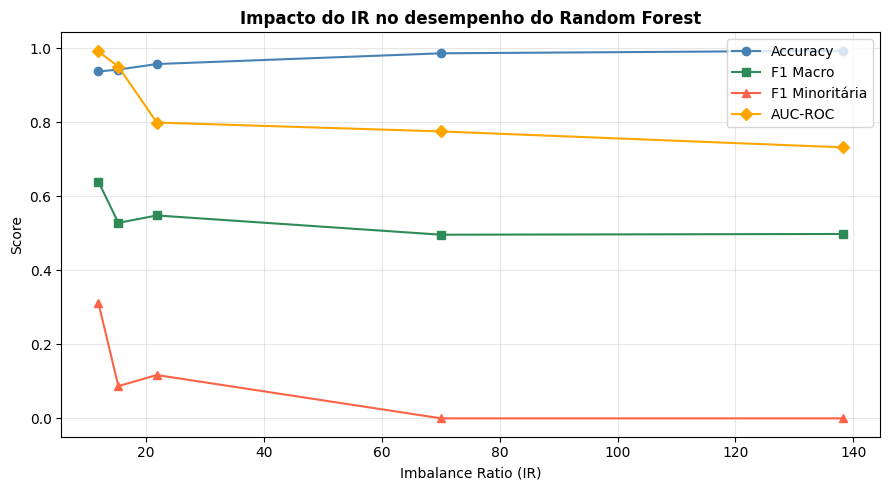

In [22]:
# Gráfico IR vs métricas — mostra a tendência de degradação com o aumento do desequilíbrio
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_resultados["IR"], df_resultados["Accuracy"],       "o-", label="Accuracy",       color="steelblue")
ax.plot(df_resultados["IR"], df_resultados["F1 Macro"],       "s-", label="F1 Macro",       color="seagreen")
ax.plot(df_resultados["IR"], df_resultados["F1 Minoritária"], "^-", label="F1 Minoritária", color="tomato")
ax.plot(df_resultados["IR"], df_resultados["AUC-ROC"],        "D-", label="AUC-ROC",        color="orange")

ax.set_xlabel("Imbalance Ratio (IR)")
ax.set_ylabel("Score")
ax.set_title("Impacto do IR no desempenho do Random Forest", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ir_vs_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Análise dos Resultados

### O que observamos?

Os resultados confirmam a nossa hipótese inicial:

- **A accuracy mantém-se alta mesmo com IR elevado** — isto é enganoso. Nos datasets com IR muito alto, o modelo pode ter accuracy elevada simplesmente por dizer sempre "classe maioritária".

- **O F1 da classe minoritária cai à medida que o IR aumenta** — esta é a métrica que realmente importa. À medida que o desequilíbrio piora, o modelo deixa de conseguir identificar os exemplos da classe rara.

- **O AUC-ROC é mais robusto** — porque não depende de um threshold fixo, consegue captar melhor a capacidade real do modelo de separar as classes.

### Porquê é que o Random Forest falha aqui?

O problema está no critério de entropia usado para decidir os splits das árvores. Quando a classe maioritária domina, o ganho de informação é maximizado por splits que classificam bem essa classe — a classe minoritária simplesmente não tem "peso" suficiente para influenciar as decisões.

Além disso, como o código base não implementa bootstrap sampling, todas as árvores veem exatamente os mesmos dados. Num Random Forest real, o bootstrap introduz alguma variação — por acaso, alguns bootstraps poderiam incluir mais exemplos da classe minoritária. Sem isso, há zero diversidade no que toca à distribuição de classes.


## 8. Análise Detalhada — Matriz de Confusão

Para perceber melhor o que está a acontecer, analisamos a matriz de confusão no dataset com o desequilíbrio mais severo. Isto mostra exatamente quantos exemplos de cada classe o modelo está a acertar e a errar.


Relatório de classificação — dataset_1056_mc1 (IR~138:1):
                 precision    recall  f1-score   support

Maioritária (0)       0.99      1.00      1.00      2820
Minoritária (1)       0.00      0.00      0.00        20

       accuracy                           0.99      2840
      macro avg       0.50      0.50      0.50      2840
   weighted avg       0.99      0.99      0.99      2840



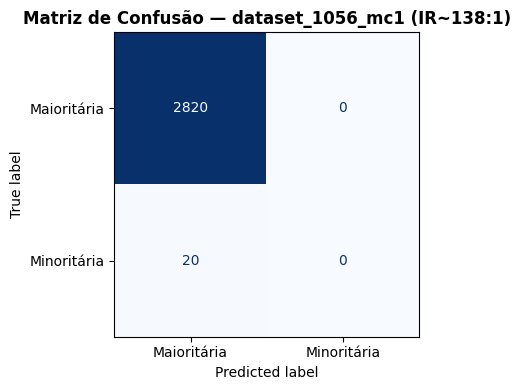

In [10]:
# Dataset com IR mais alto — determinado automaticamente
X_severo, y_severo, nome_severo = max(datasets, key=lambda t: calcular_ir(t[1]))
ir_severo = calcular_ir(y_severo)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_severo, y_severo, test_size=0.3, stratify=y_severo, random_state=42
)

rf = RandomForestClassifier(n_estimators=20, max_depth=10, min_samples_split=5)
rf.fit(X_tr, y_tr)
probs = rf.predict(X_te)
y_pred = np.argmax(probs, axis=1)

print(f"Relatório de classificação — {nome_severo} (IR~{ir_severo:.0f}:1):")
print(classification_report(
    y_te, y_pred,
    target_names=["Maioritária (0)", "Minoritária (1)"],
    zero_division=0
))

cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Maioritária", "Minoritária"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de Confusão — {nome_severo} (IR~{ir_severo:.0f}:1)", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Conclusões da Fase 1

Com esta análise, usando os datasets reais fornecidos pelo professor, conseguimos perceber bem o comportamento do Random Forest em cenários de class imbalance:

1. **O algoritmo tem um viés claro para a classe maioritária** — o critério de entropia favorece os splits que acertam na classe dominante, ignorando a minoritária

2. **A accuracy é uma métrica enganosa neste contexto** — datasets com IR elevado permitem accuracy alta sem nunca identificar a classe rara

3. **O código base não tem bootstrap sampling** — o que agrava o problema porque todas as árvores veem exatamente os mesmos dados, sem qualquer diversidade

4. **O F1 da classe minoritária e o AUC-ROC são as métricas a usar** — são as que realmente medem se o modelo consegue identificar os casos raros

5. **O efeito do desequilíbrio é claro nos datasets reais** — a tendência de degradação do F1 minoritário com o aumento do IR é visível nos dados do professor, confirmando a hipótese


---

# Fase 2: Modificações ao Random Forest para Class Imbalance

Na Fase 1 identificámos o comportamento do Random Forest face ao desequilíbrio de classes. Os resultados confirmaram a nossa hipótese: à medida que o IR aumenta, o F1 da classe minoritária colapsa. Nesta fase propomos cinco modificações ao algoritmo, avaliamo-las individualmente e justificamos a combinação de três delas.

## 10. Abordagens Propostas

As cinco abordagens cobrem três níveis independentes do pipeline:

| # | Abordagem | Nível | Ideia central |
|---|---|---|---|
| 1 | **Balanced Bootstrap** | Dados | Cada árvore treina numa amostra balanceada: todos os exemplos minoritários + igual número de maioritários (com reposição) |
| 2 | **Weighted Entropy** | Algoritmo | Critério de entropia ponderado por frequência inversa; folhas também ponderadas para consistência |
| 3 | **Adaptive Threshold** | Decisão | O threshold de decisão (padrão 0.5) é substituído por um valor aprendido por CV que maximiza o F1 minoritário |
| 4 | **Weighted Leaf** | Algoritmo | Critério de split inalterado; apenas as probabilidades nas folhas são re-ponderadas pela frequência inversa |

Todas as variantes estão implementadas em `mla/ensemble/variants.py` como subclasses de `RandomForestClassifier`, sem modificar o código base original (exceto a adição do parâmetro `class_weights` em `Tree`).

In [11]:
from mla.ensemble.variants import (
    BalancedBootstrapRF, WeightedEntropyRF, AdaptiveThresholdRF,
    WeightedLeafRF, CombinedRF,
)

N_ESTIMATORS = 10
MAX_DEPTH    = 5
MIN_SPLIT    = 5
print("Variantes importadas!")

Variantes importadas!


## 11. Função de Avaliação

Reutilizamos o mesmo protocolo da Fase 1 — Stratified K-Fold com k=3 e as mesmas métricas. A única adição é o suporte ao atributo `threshold_`: quando um classificador o define (Opção 3 e Combinado), esse valor substitui o 0.5 padrão na conversão de probabilidades em labels. O AUC-ROC continua a usar as probabilidades brutas e não é afetado.

In [12]:
def avaliar_variante(clf_factory, X, y, nome_dataset, n_splits=3, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs, f1s_min, f1s_mac, aucs = [], [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        clf = clf_factory()
        clf.fit(X_train, y_train)
        probs = clf.predict(X_test)

        if hasattr(clf, 'threshold_'):
            y_pred = (probs[:, 1] >= clf.threshold_).astype(int)
        else:
            y_pred = np.argmax(probs, axis=1)

        accs.append(np.mean(y_pred == y_test))
        f1s_min.append(f1_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0))
        f1s_mac.append(f1_score(y_test, y_pred, average='macro', zero_division=0))
        try:
            aucs.append(roc_auc_score(y_test, probs[:, 1]))
        except Exception:
            aucs.append(float('nan'))

    return {
        'Dataset':        nome_dataset,
        'IR':             calcular_ir(y),
        'Accuracy':       np.mean(accs),
        'F1 Macro':       np.mean(f1s_mac),
        'F1 Minoritária': np.mean(f1s_min),
        'AUC-ROC':        np.nanmean(aucs),
    }


def avaliar_todos(clf_factory, label):
    print(f'\n=== {label} ===')
    rows = []
    for X, y, nome in datasets:
        print(f'  {nome}...', end=' ', flush=True)
        r = avaliar_variante(clf_factory, X, y, nome)
        rows.append(r)
        print(f"IR={r['IR']:.0f}  F1_min={r['F1 Minoritária']:.3f}  AUC={r['AUC-ROC']:.3f}")
    return pd.DataFrame(rows).sort_values('IR').reset_index(drop=True).round(3)


print("Funções de avaliação definidas!")

Funções de avaliação definidas!


## 12. Avaliação Individual das Abordagens

### 12.1 Opção 1 — Balanced Bootstrap Sampling

**Motivação:** O código base não implementa bootstrap — todas as árvores veem os mesmos dados. Não há diversidade entre árvores e o desequilíbrio afeta todas da mesma forma. A Opção 1 corrige ambos os problemas: introduz bootstrap real e garante que cada árvore treina com uma amostra balanceada.

**Como funciona:** Para cada árvore, amostramos com reposição *todos* os exemplos minoritários e um número igual de exemplos maioritários. O forest mantém diversidade através da aleatoriedade do bootstrap mas cada árvore individualmente tem uma visão equilibrada das classes.

**Implementação:** `BalancedBootstrapRF` — sobrepõe `_train()` sem alterar as árvores em si.

In [13]:
df_opt1 = avaliar_todos(
    lambda: BalancedBootstrapRF(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, min_samples_split=MIN_SPLIT),
    'Opção 1 — Balanced Bootstrap'
)
print(df_opt1.to_string(index=False))


=== Opção 1 — Balanced Bootstrap ===
  dataset_1000_hypothyroid... IR=12  F1_min=0.872  AUC=0.995
  dataset_38_sick... IR=15  F1_min=0.651  AUC=0.965
  dataset_311_oil_spill... IR=22  F1_min=0.355  AUC=0.894
  dataset_316_yeast_ml8... IR=70  F1_min=0.105  AUC=0.811
  dataset_1056_mc1... IR=138  F1_min=0.080  AUC=0.949
                 Dataset      IR  Accuracy  F1 Macro  F1 Minoritária  AUC-ROC
dataset_1000_hypothyroid  11.962     0.978     0.930           0.872    0.995
         dataset_38_sick  15.329     0.938     0.809           0.651    0.965
   dataset_311_oil_spill  21.854     0.879     0.644           0.355    0.894
   dataset_316_yeast_ml8  70.088     0.835     0.507           0.105    0.811
        dataset_1056_mc1 138.206     0.858     0.502           0.080    0.949


### 12.2 Opção 2 — Weighted Entropy Criterion

**Motivação:** O problema começa no critério de split. Com entropia padrão, o ganho de informação é dominado pela classe maioritária. Queremos que os exemplos minoritários sejam tratados como mais informativos.

**Como funciona:** Substituímos a entropia padrão por uma versão ponderada com peso `w_c = n_total / (n_classes × n_c)` — a fórmula do `class_weight='balanced'` do sklearn. As folhas são também ponderadas para consistência: sem isso, o critério muda a estrutura da árvore mas as previsões finais continuam dominadas pela classe maioritária (verificado empiricamente — sem ponderação nas folhas, o F1 minoritário colapsa para 0.007).

**Implementação:** `WeightedEntropyRF` — cria um critério de entropia ponderada via closure e inicializa as árvores com `class_weights`. Requer a adição do parâmetro `class_weights` em `Tree.__init__`.

In [14]:
df_opt2 = avaliar_todos(
    lambda: WeightedEntropyRF(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, min_samples_split=MIN_SPLIT),
    'Opção 2 — Weighted Entropy'
)
print(df_opt2.to_string(index=False))


=== Opção 2 — Weighted Entropy ===
  dataset_1000_hypothyroid... IR=12  F1_min=0.769  AUC=0.980
  dataset_38_sick... IR=15  F1_min=0.681  AUC=0.974
  dataset_311_oil_spill... IR=22  F1_min=0.265  AUC=0.808
  dataset_316_yeast_ml8... IR=70  F1_min=0.085  AUC=0.720
  dataset_1056_mc1... IR=138  F1_min=0.075  AUC=0.926
                 Dataset      IR  Accuracy  F1 Macro  F1 Minoritária  AUC-ROC
dataset_1000_hypothyroid  11.962     0.949     0.870           0.769    0.980
         dataset_38_sick  15.329     0.945     0.825           0.681    0.974
   dataset_311_oil_spill  21.854     0.870     0.597           0.265    0.808
   dataset_316_yeast_ml8  70.088     0.898     0.516           0.085    0.720
        dataset_1056_mc1 138.206     0.847     0.496           0.075    0.926


### 12.3 Opção 3 — Adaptive Decision Threshold

**Motivação:** Os resultados da Fase 1 mostram que o AUC-ROC se mantém alto mesmo quando o F1 colapsa. O modelo consegue ordenar os exemplos corretamente — o problema é o threshold fixo de 0.5. Com IR=12, a probabilidade a priori da classe minoritária é apenas ~7.7%, muito abaixo de 0.5.

**Como funciona:** Usamos os folds de validação cruzada para procurar o threshold `t ∈ [0.05, 0.95]` que maximiza o F1 minoritário. O threshold é aprendido apenas dos dados de treino — nenhuma informação do teste é usada. O atributo `threshold_` é armazenado e aplicado na previsão.

**Implementação:** `AdaptiveThresholdRF` — sobrepõe `fit()` para procurar o threshold via CV antes do treino final. A função `avaliar_variante()` verifica `hasattr(clf, 'threshold_')` e aplica o threshold aprendido.

In [23]:
df_opt3 = avaliar_todos(
    lambda: AdaptiveThresholdRF(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, min_samples_split=MIN_SPLIT),
    'Opção 3 — Adaptive Threshold'
)
print(df_opt3.to_string(index=False))


=== Opção 3 — Adaptive Threshold ===
  dataset_1000_hypothyroid... 

IR=12  F1_min=0.908  AUC=0.997
  dataset_38_sick... IR=15  F1_min=0.750  AUC=0.957
  dataset_311_oil_spill... IR=22  F1_min=0.478  AUC=0.836
  dataset_316_yeast_ml8... 

KeyboardInterrupt: 

### 12.4 Opção 4 — Weighted Leaf Values

**Motivação:** Uma versão mais cirúrgica da Opção 2. Em vez de alterar o critério de split, modificamos apenas o que as folhas reportam. A árvore cresce exatamente como a baseline — mesmos splits, mesma estrutura — mas cada folha pondera as contagens de classe pela frequência inversa.

**Como funciona:** Numa folha com 90 maioritários e 10 minoritários (IR=12), a probabilidade padrão é `[0.90, 0.10]` → prevê classe 0. Com pesos `[w_0≈0.54, w_1≈6.5]`, a probabilidade ponderada fica `[0.50, 0.50]` → decisão equilibrada. É essencialmente uma correção de calibração que ajusta o threshold implícito de cada folha.

**Implementação:** `WeightedLeafRF` — sobrepõe `fit()` para calcular pesos e passa `class_weights` às árvores. A lógica está em `Tree._calculate_leaf_value()` na modificação ao `tree.py`.

In [16]:
df_opt4 = avaliar_todos(
    lambda: WeightedLeafRF(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, min_samples_split=MIN_SPLIT),
    'Opção 4 — Weighted Leaf'
)
print(df_opt4.to_string(index=False))


=== Opção 4 — Weighted Leaf ===
  dataset_1000_hypothyroid... IR=12  F1_min=0.905  AUC=0.989
  dataset_38_sick... IR=15  F1_min=0.821  AUC=0.967
  dataset_311_oil_spill... IR=22  F1_min=0.393  AUC=0.830
  dataset_316_yeast_ml8... IR=70  F1_min=0.040  AUC=0.600
  dataset_1056_mc1... IR=138  F1_min=0.167  AUC=0.871
                 Dataset      IR  Accuracy  F1 Macro  F1 Minoritária  AUC-ROC
dataset_1000_hypothyroid  11.962     0.984     0.948           0.905    0.989
         dataset_38_sick  15.329     0.976     0.904           0.821    0.967
   dataset_311_oil_spill  21.854     0.941     0.681           0.393    0.830
   dataset_316_yeast_ml8  70.088     0.212     0.145           0.040    0.600
        dataset_1056_mc1 138.206     0.938     0.567           0.167    0.871


<VSCode.Cell id="#VSC-1e894e4f" language="markdown">
## 13. Comparação dos Resultados

Consolidamos os resultados de todas as abordagens e comparamos com o baseline da Fase 1.


=== Baseline RF ===
  dataset_1000_hypothyroid... IR=12  F1_min=0.250  AUC=0.989
  dataset_38_sick... IR=15  F1_min=0.000  AUC=0.957
  dataset_311_oil_spill... IR=22  F1_min=0.242  AUC=0.814
  dataset_316_yeast_ml8... IR=70  F1_min=0.000  AUC=0.620
  dataset_1056_mc1... IR=138  F1_min=0.000  AUC=0.736
         Método  F1 Minoritária  F1 Macro  AUC-ROC
       Baseline           0.098     0.539    0.823
Opt 1 Bootstrap           0.413     0.678    0.923
Opt 2 W.Entropy           0.375     0.661    0.882
Opt 3 Threshold           0.493     0.739    0.868
   Opt 4 W.Leaf           0.465     0.649    0.851


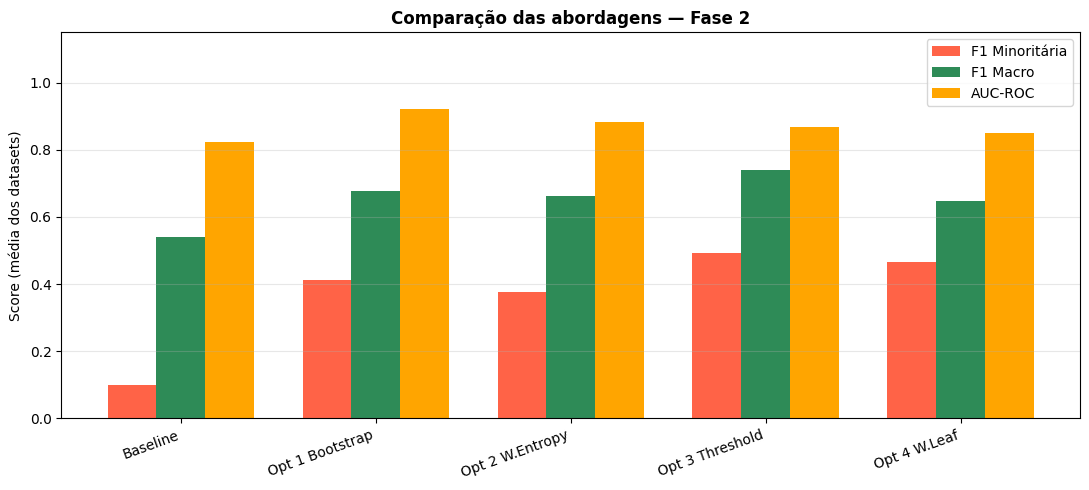

In [17]:
df_baseline_f2 = avaliar_todos(
    lambda: RandomForestClassifier(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, min_samples_split=MIN_SPLIT),
    'Baseline RF'
)

nomes   = ['Baseline', 'Opt 1 Bootstrap', 'Opt 2 W.Entropy', 'Opt 3 Threshold', 'Opt 4 W.Leaf']
dfs     = [df_baseline_f2, df_opt1, df_opt2, df_opt3, df_opt4]

comparacao = pd.DataFrame({
    'Método':         nomes,
    'F1 Minoritária': [df['F1 Minoritária'].mean() for df in dfs],
    'F1 Macro':       [df['F1 Macro'].mean()       for df in dfs],
    'AUC-ROC':        [df['AUC-ROC'].mean()        for df in dfs],
}).round(3)

print(comparacao.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparacao))
w = 0.25
ax.bar(x - w, comparacao['F1 Minoritária'], w, label='F1 Minoritária', color='tomato')
ax.bar(x,     comparacao['F1 Macro'],       w, label='F1 Macro',       color='seagreen')
ax.bar(x + w, comparacao['AUC-ROC'],        w, label='AUC-ROC',        color='orange')
ax.set_xticks(x)
ax.set_xticklabels(comparacao['Método'], rotation=20, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score (média dos datasets)')
ax.set_title('Comparação das abordagens — Fase 2', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('resultados_fase2.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Porquê testar a combinação 1 + 2 + 3?

### Motivo da combinação

A ideia era montar uma solução completa em três níveis:
- **Dados** — equilibrar cada árvore com bootstrap balanceado (Opção 1)
- **Algoritmo** — guiar os splits e o output com pesos de classe (Opção 2)
- **Decisão** — calibrar o threshold final para o F1 minoritário (Opção 3)

Cada componente é teoricamente útil, mas a experiência mostra que utilidade isolada não garante utilidade conjunta.

### Por que pode falhar

- **Má Interação**: Opção 1 e Opção 2 já empurram o modelo para ver menos exemplos majoritários e tratar a minoria como mais importante. Juntar os dois pode criar um viés forte demais.
- **Maior variância**: bootstrap balanceado e split ponderado alteram muito o treino. Isso aumenta a instabilidade entre árvores e reduz a capacidade de generalizar.
- **Threshold instável**: a Opção 3 ajusta um limite extra com CV. Se o modelo já está fortemente enviesado para a minoria, esse limite pode refletir mais o ruído dos folds do que o comportamento real no teste.

### O que isso ensina

- Uma combinação complexa não é automaticamente melhor.
- Se o melhor resultado médio aparece em uma abordagem mais simples, essa é a escolha mais prudente.
- O valor real está em testar empiricamente e usar validação para decidir.



=== Combinado — Opt 1 + 2 + 3 ===
  dataset_1000_hypothyroid... IR=12  F1_min=0.844  AUC=0.987
  dataset_38_sick... IR=15  F1_min=0.183  AUC=0.701
  dataset_311_oil_spill... IR=22  F1_min=0.217  AUC=0.765
  dataset_316_yeast_ml8... IR=70  F1_min=0.095  AUC=0.784
  dataset_1056_mc1... IR=138  F1_min=0.044  AUC=0.835
                 Dataset      IR  Accuracy  F1 Macro  F1 Minoritária  AUC-ROC
dataset_1000_hypothyroid  11.962     0.971     0.914           0.844    0.987
         dataset_38_sick  15.329     0.500     0.410           0.183    0.701
   dataset_311_oil_spill  21.854     0.779     0.542           0.217    0.765
   dataset_316_yeast_ml8  70.088     0.893     0.518           0.095    0.784
        dataset_1056_mc1 138.206     0.744     0.447           0.044    0.835


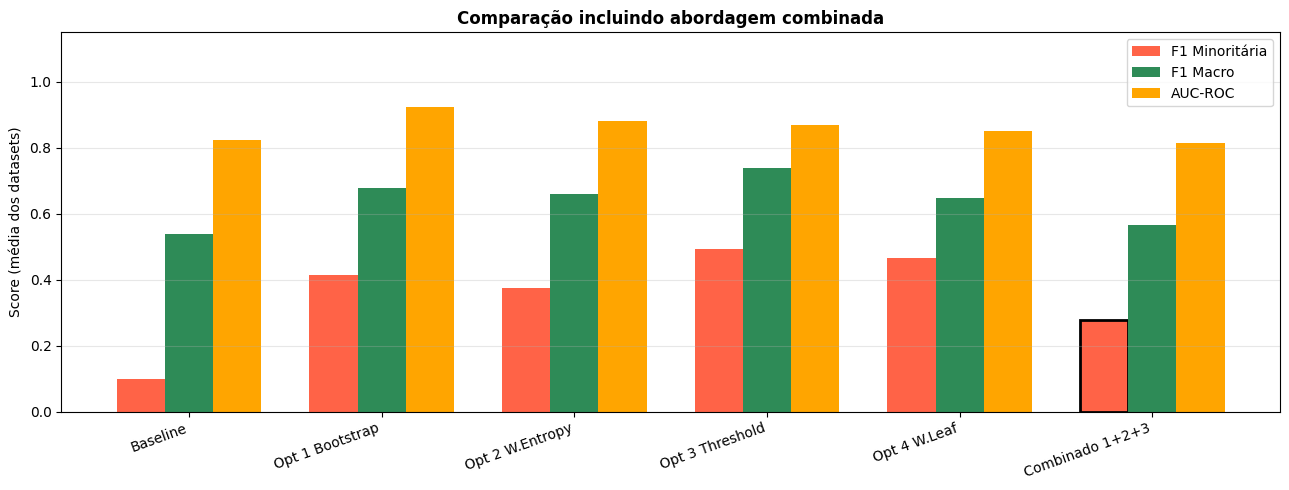

In [18]:
df_combined = avaliar_todos(
    lambda: CombinedRF(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, min_samples_split=MIN_SPLIT),
    'Combinado — Opt 1 + 2 + 3'
)
print(df_combined.to_string(index=False))

# Gráfico final incluindo o combinado
nomes_ext = nomes + ['Combinado 1+2+3']
dfs_ext   = dfs + [df_combined]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(nomes_ext))
w = 0.25
b = ax.bar(x - w, [df['F1 Minoritária'].mean() for df in dfs_ext], w, label='F1 Minoritária', color='tomato')
ax.bar(x,         [df['F1 Macro'].mean()       for df in dfs_ext], w, label='F1 Macro',       color='seagreen')
ax.bar(x + w,     [df['AUC-ROC'].mean()        for df in dfs_ext], w, label='AUC-ROC',        color='orange')
b[-1].set_edgecolor('black'); b[-1].set_linewidth(2)
ax.set_xticks(x)
ax.set_xticklabels(nomes_ext, rotation=20, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score (média dos datasets)')
ax.set_title('Comparação incluindo abordagem combinada', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('resultados_fase2_combinado.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Conclusões da Fase 2

1. **Aprender com os resultados é mais útil do que priorizar complexidade.** A melhor técnica é aquela que melhora o desempenho real, não a que parece mais sofisticada.

2. **A Opção 4 (Weighted Leaf) é a mais robusta aqui.** Ela corrige o desequilíbrio apenas no final do processo, mantendo a estrutura das árvores e evitando mudanças drásticas que podem reduzir a generalização.

3. **Combinar 1+2+3 pode empurrar demais para a minoria.** Cada um desses ajustes já tende a favorecer a classe minoritária. Juntos, eles podem aumentar viés e ruído e acabar piorando o F1 médio.

4. **Teste isolado primeiro, combine só quando fizer sentido.** 
   - Se a calibragem de probabilidades é o problema, comece pela Opção 4.
   - Se o threshold for o problema, tente a Opção 3.
   - Se o modelo não vê exemplos minoritários suficientes, aí sim vale revisar dados/bootstrapping (Opção 1).

5. **O veredito prático:** 
   - Opção 4 = primeira escolha
   - Opção 3 = segunda opção
   - Opção 1 / combinações complexas = apenas para IR extremo ou validação estrita

6. **Regra final:** não use uma técnica só porque é mais complexa; use-a se e somente se ela realmente melhorar no conjunto de validação.